In [11]:
import numpy as np 
from BaselineRemoval import BaselineRemoval as br

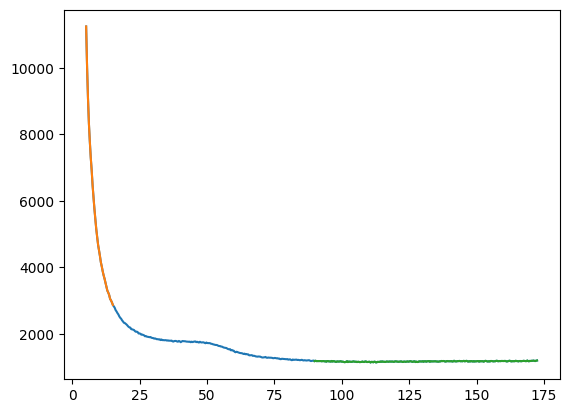

In [219]:
data = np.loadtxt(r'12--1_4v_01.txt')
import matplotlib.pyplot as plt
data = data[525:]

plt.figure()
plt.plot(data[:, 0], data[:, -1])
start_id = 30
end_id = 250
plt.plot(data[:start_id, 0], data[:start_id, -1])
plt.plot(data[end_id:, 0], data[end_id:, -1])


In [220]:
new_data = np.r_[data[:start_id, -1], data[end_id:, -1]]

In [221]:
new_data = data[:, -1].copy()

In [222]:
left = data[:start_id, -1].copy()
right = data[end_id:, -1].copy()

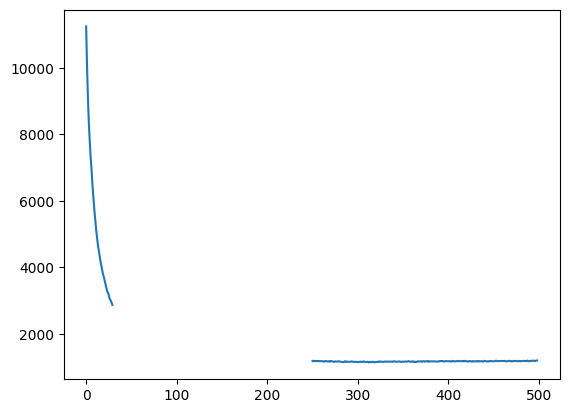

In [223]:
new_data[start_id:end_id] = np.nan
plt.plot(new_data)

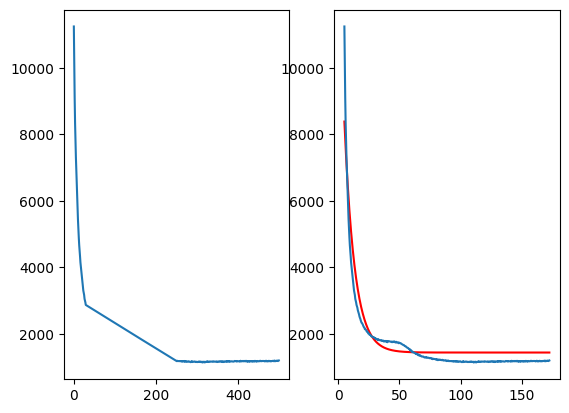

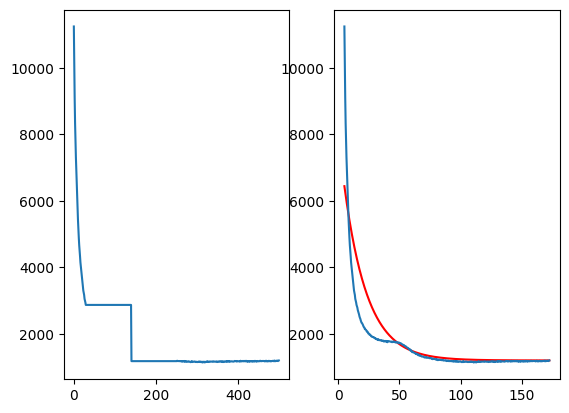

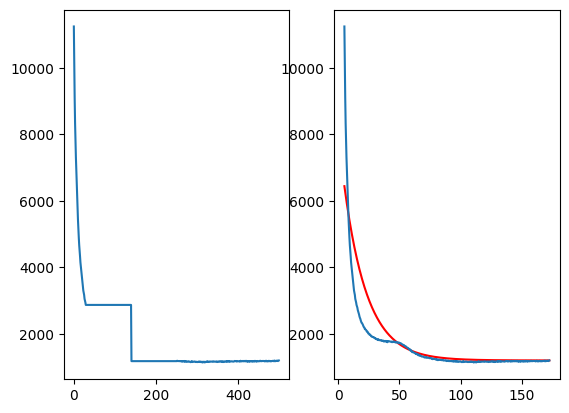

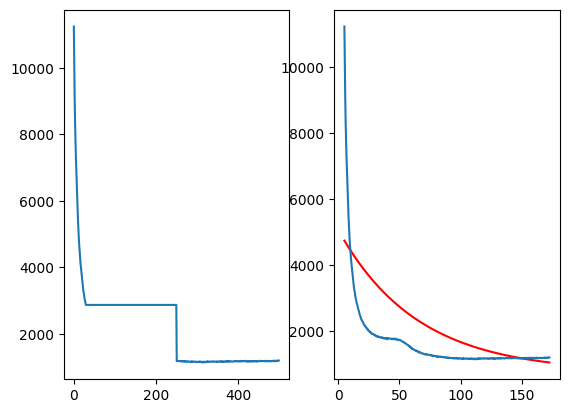

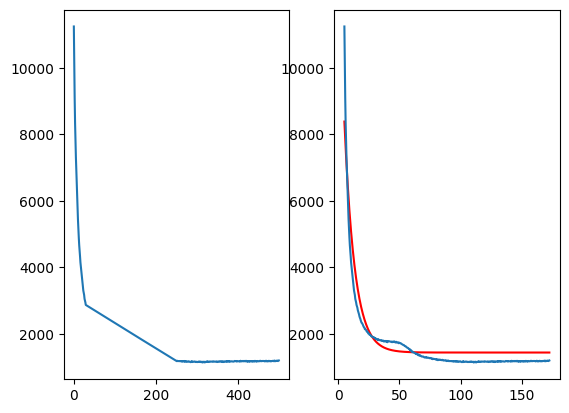

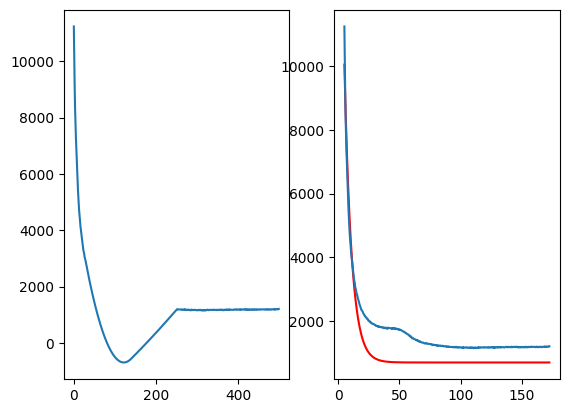

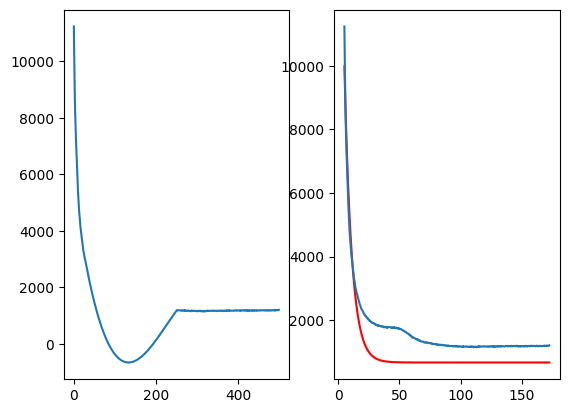

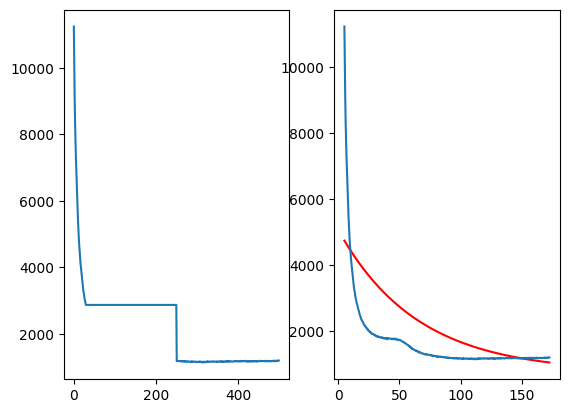

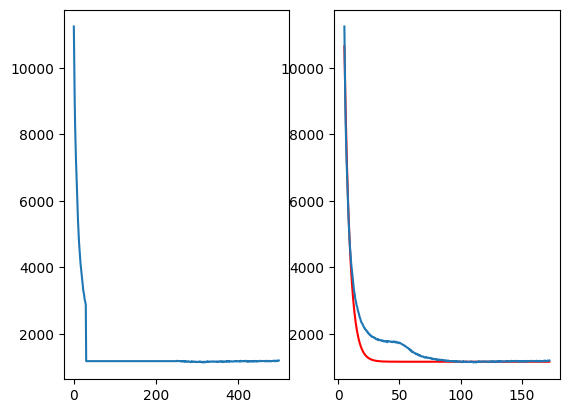

In [224]:
from scipy.interpolate import interp1d
# Create a mask to identify NaN values
nan_mask = np.isnan(new_data)
res = new_data.copy()
for k in ['linear', 'nearest', 'nearest-up', 'zero', 'slinear', 'quadratic', 'cubic', 'previous', 'next']:
# Replace NaN values with linearly interpolated values for smoother fitting
    plt.figure()
    func = interp1d(data[~nan_mask, 0], new_data[~nan_mask], kind=k)
    res[nan_mask] = func(data[nan_mask, 0])
    plt.subplot(121)
    plt.plot(res)
    plt.subplot(122)
    #curve_fit
    from scipy.optimize import curve_fit
    def func(x, a, b, c, ):
        return a * np.exp(-b * x) + c 
    popt, pcov = curve_fit(func, data[:, 0], res)
    plt.plot(data[:, 0], func(data[:, 0], *popt), 'r-',
            label='fit: a=%5.3f, b=%5.3f, c=%5.3f' % tuple(popt))
    plt.plot(data[:, 0], data[:, -1])

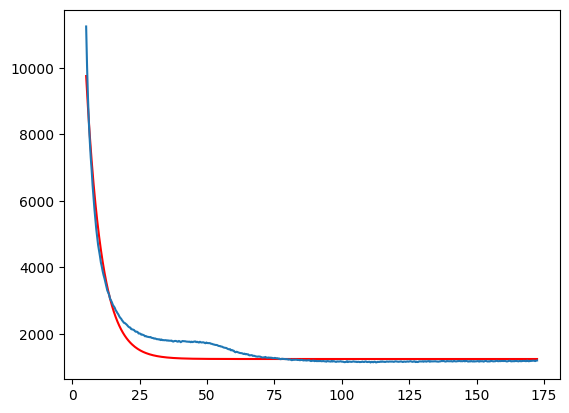

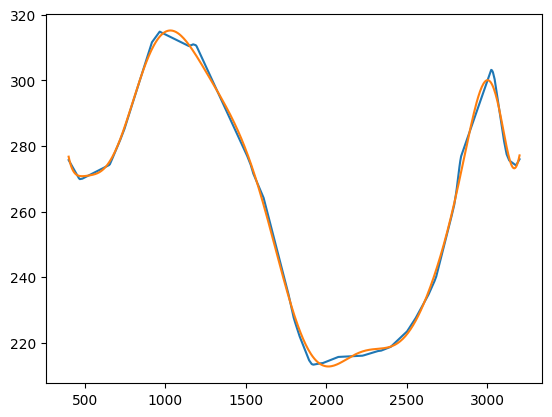

In [19]:
# plt.plot(data[:, 0], data[:, -1])
plt.plot(data[:, 0], data[:, -1] - res)
plt.plot(data[:, 0], func(data[:, 0]))

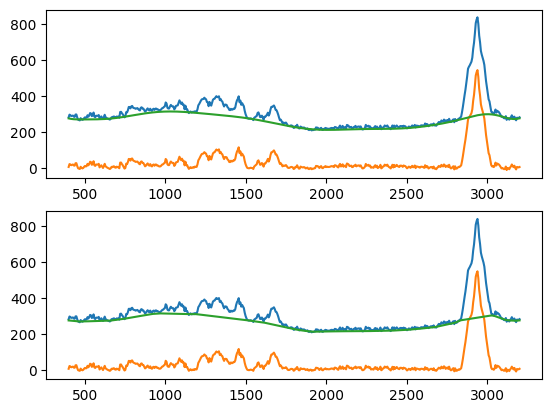

In [24]:
plt.subplot(211)
plt.plot(data[:, 0], data[:, -1])
plt.plot(data[:, 0], data[:, -1] - func(data[:, 0]))
plt.plot(data[:, 0], func(data[:, 0]))
plt.subplot(212)
plt.plot(data[:, 0], data[:, -1])
plt.plot(data[:, 0], res)
plt.plot(data[:, 0], data[:, -1] - res)
